# Gold Price Prediction

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [14]:
ticker = yf.Ticker("B")
df = ticker.history(period="1mo")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-08-05 00:00:00-04:00,21.930000,22.570000,21.809999,22.540001,12945200,0.0,0.0
2025-08-06 00:00:00-04:00,22.610001,22.950001,22.530001,22.730000,13137700,0.0,0.0
2025-08-07 00:00:00-04:00,23.000000,23.410000,22.950001,23.070000,18825700,0.0,0.0
2025-08-08 00:00:00-04:00,23.370001,23.540001,23.160000,23.430000,19398500,0.0,0.0
2025-08-11 00:00:00-04:00,22.360001,22.910000,22.129999,22.840000,17365400,0.0,0.0


In [20]:
x = df['Close'].pct_change() * 100
y = df.Return.shift()
df = df.dropna()

In [33]:
mask = ~pd.isna(x) & ~pd.isna(y)
x_clean = x[mask]
y_clean = y[mask]

x_train, x_test, y_train, y_test = train_test_split(
    x_clean, y_clean, test_size=0.2, random_state=42
)

In [34]:
x_train = np.array(x_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)
x_test = np.array(x_test).reshape(-1,1)
y_test = np.array(y_test).reshape(-1,1)

In [35]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (15, 1)
y_train shape: (15, 1)
x_test shape: (4, 1)
y_test shape: (4, 1)


In [36]:
print("NaNs in x_train:", np.isnan(x_train).sum())
print("NaNs in x_test:", np.isnan(x_test).sum())
print("NaNs in y_train:", pd.isna(y_train).sum())
print("NaNs in y_test:", pd.isna(y_test).sum())

NaNs in x_train: 0
NaNs in x_test: 0
NaNs in y_train: 0
NaNs in y_test: 0


## Using Linear regression model

In [37]:
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

In [38]:
print(predictions)

[[0.82883185]
 [0.77654355]
 [0.9679627 ]
 [1.28094569]]


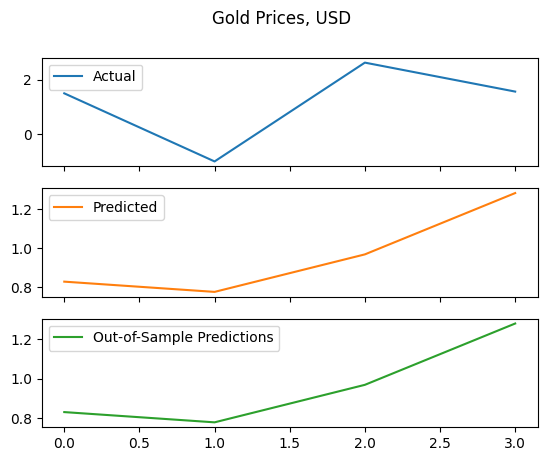

In [41]:
import matplotlib.pyplot as plt
preds = model.predict(x_test).ravel()
out_of_sample_results = pd.DataFrame({
    "Actual": y_test.ravel(),
    "Predicted": preds
})
out_of_sample_results['Out-of-Sample Predictions'] = model.predict(x_test)
out_of_sample_results.plot(subplots=True,title='Gold Prices, USD')
plt.show()